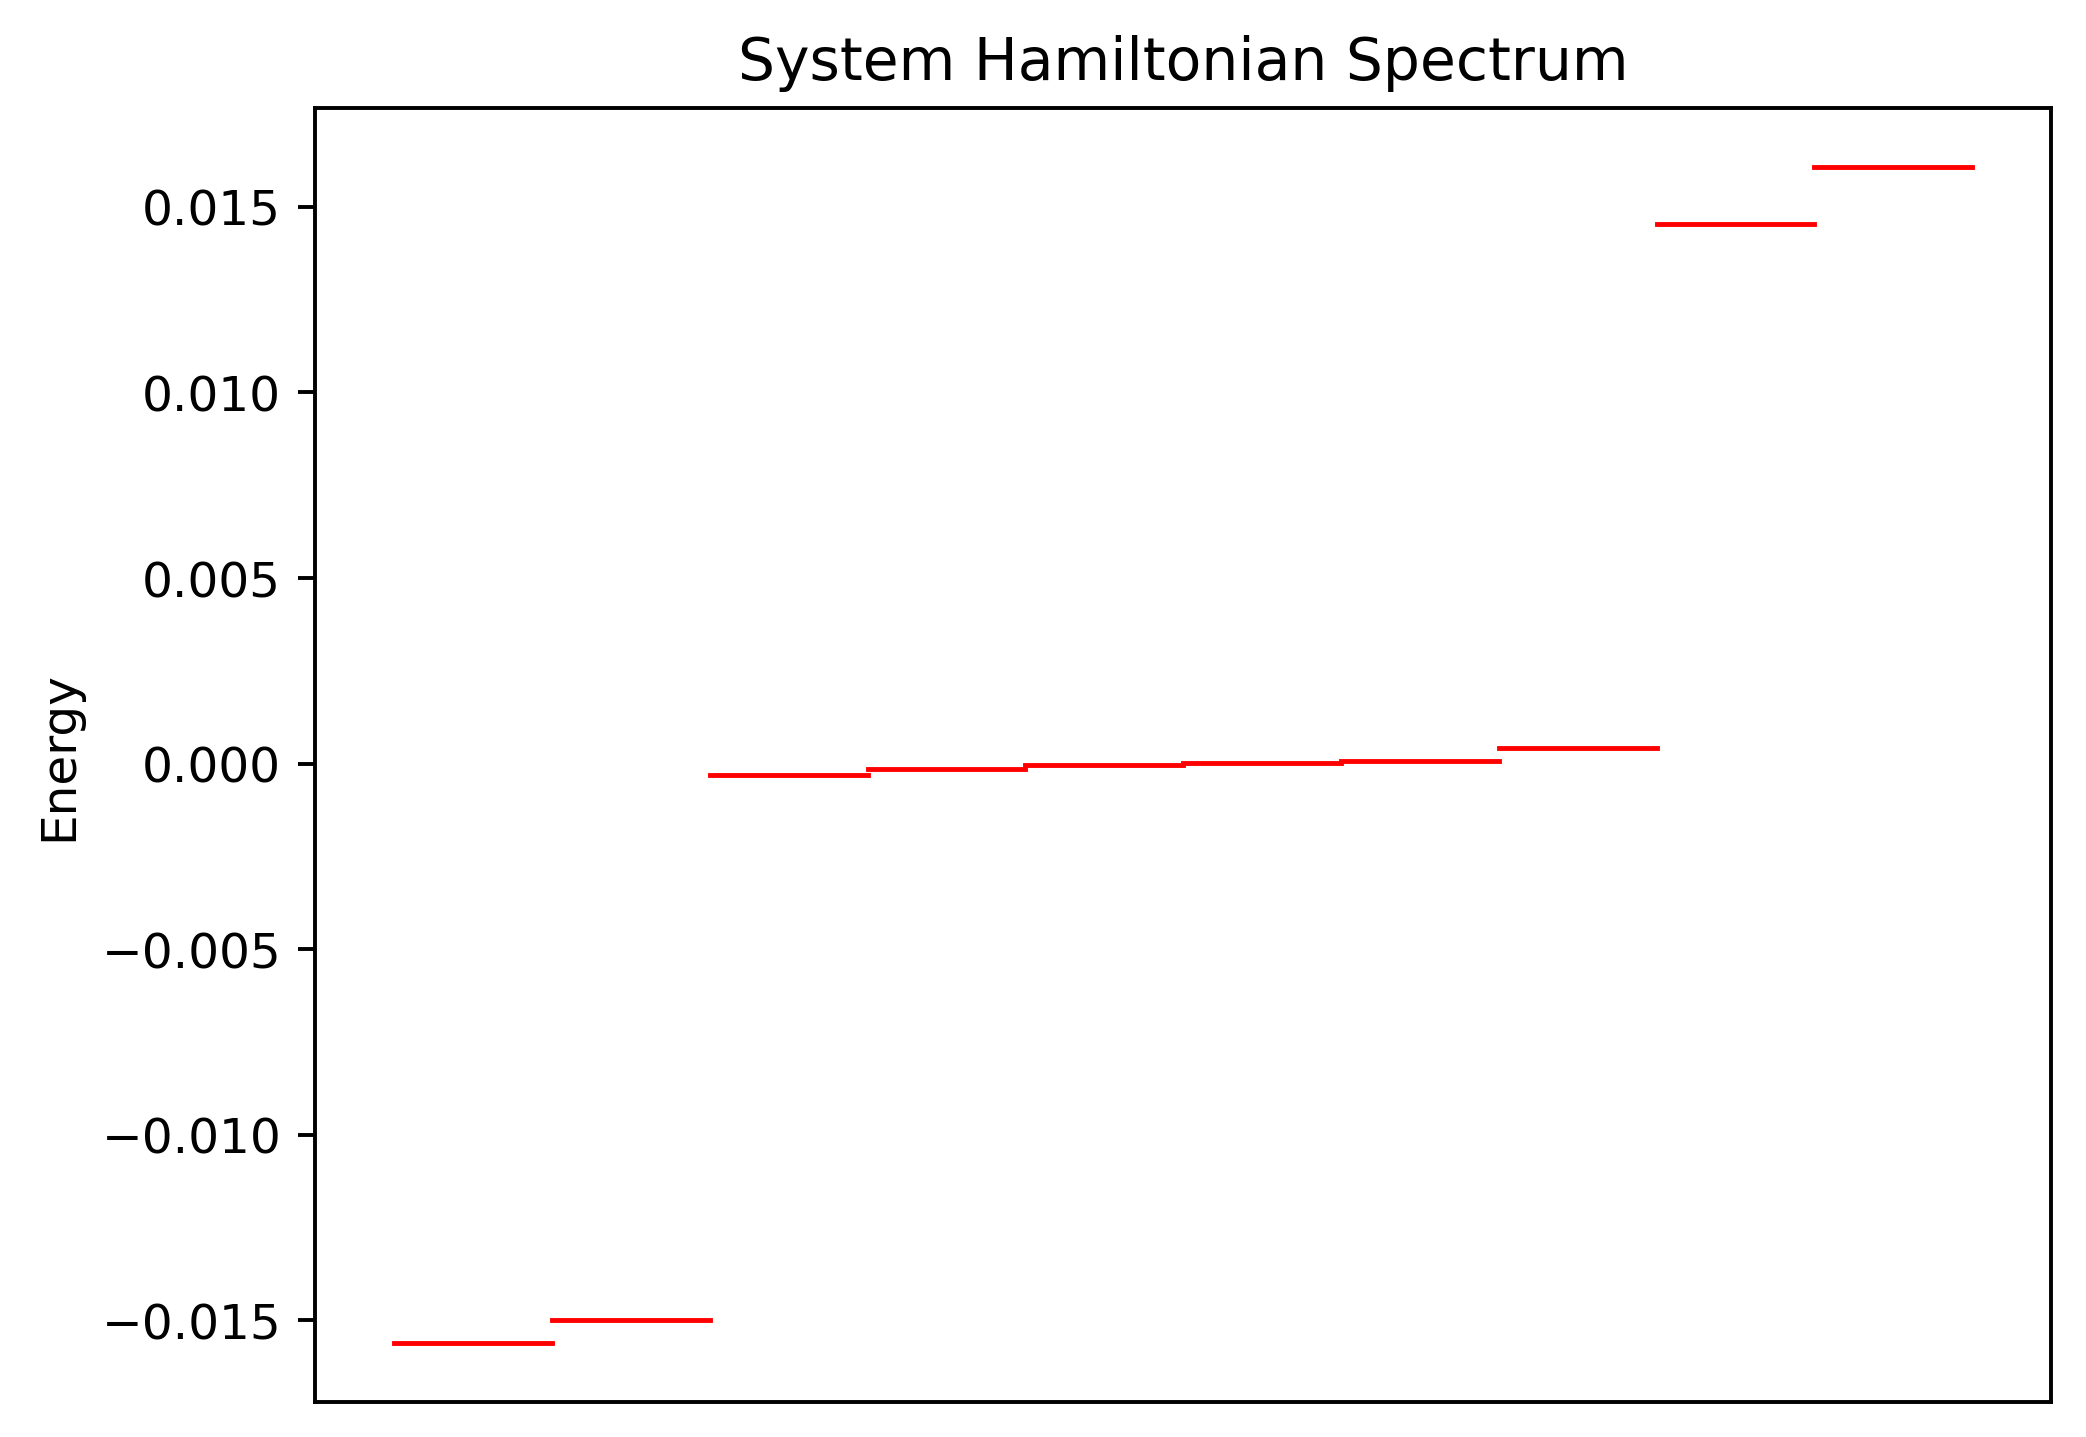

trace= 1.0000000000000004


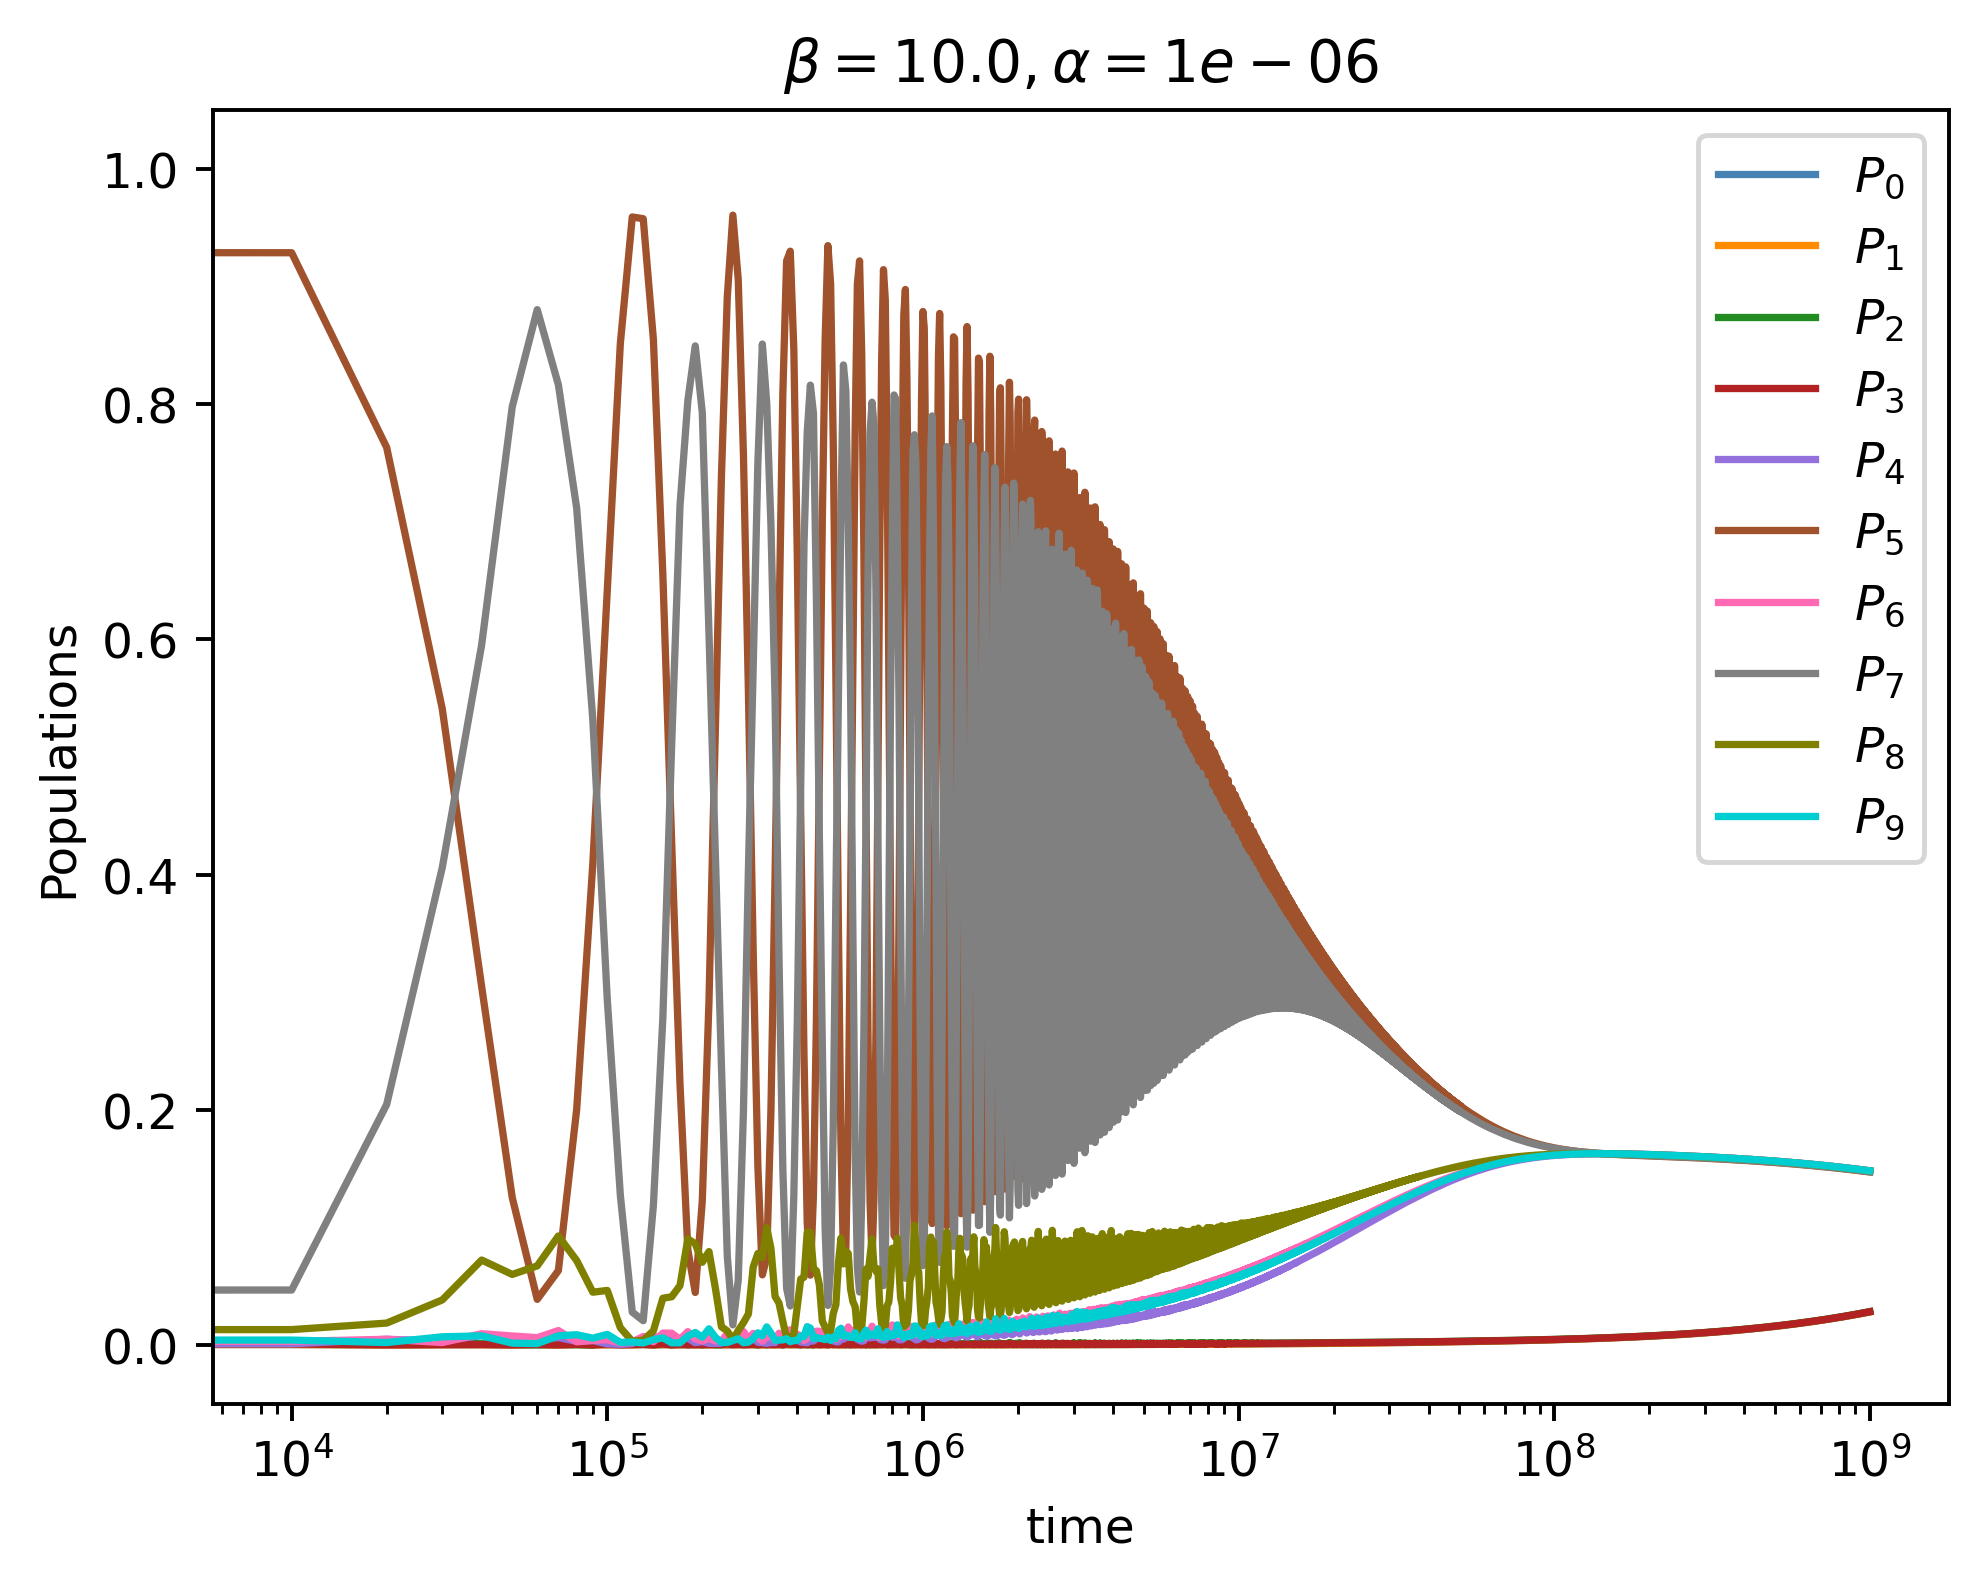

In [3]:
%matplotlib inline
import numpy as np
from utils import _build_redfield_numba, build_redfield_tensor, evolve_density_matrix
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
plt.rcParams['figure.dpi']=350

N=10
#coupling params
J_max = 1
power = 3 #power for coupling matrix/system hamiltonain - 3 for dipole-dipole like model

#bath params- assuming N decoupled ohmic baths with same alpha, beta, omega_c
alpha_list=np.array(1e-6*np.ones(N)) 
wc_list=np.array(50*np.ones(N))
beta_list=np.array(10*np.ones(N))


#to generate configurations A or B use one of the following distance arrays
#generate configuration B 
D = np.array([[ 26.42338043,  -7.94752626],
              [ 23.5676572 , -10.82584156],
              [ 12.9945502 , -15.04985626],
              [ 10.04355896, -17.75500788],
              [ 22.09827259,  11.50615309],
              [  4.77769072, -29.50708222],
              [  3.61769485,  13.64602815],
              [-13.15603736,  -3.06908283],
              [ -7.72037927,  25.74900317],
              [-22.17787943,  18.52470886]])

#generate configuration A  
'''D=np.array([[ 31.53553015,   3.44199744],
              [ 29.69692277,   2.38201959],
              [ 29.78424968,   6.90942031],
              [ 11.22998167,   8.6657443 ],
              [ 11.4583447 ,  -2.66983921],
              [ 13.21948377, -17.481802  ],
              [  0.64608129,  21.77132371],
              [  5.82726916, -30.27930513],
              [-15.20226319, -15.91983595],
              [-15.69793743,  24.45663107]])
'''
#system hamiltonian in local basis, degenerate case
N = D.shape[0]
H = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        if i != j:
            dist = np.linalg.norm(D[i] - D[j])
            H[i, j] = J_max / dist**power

#plot Hamiltonian spectrum

energies,evectors=np.linalg.eigh(H)
plt.figure()
for energy,k in zip(energies,range(len(energies))):
    x=1/2*np.linspace(k,k+1)
    plt.plot(x,energy*np.ones_like(x),color='r',lw=1)
plt.ylabel('Energy')
plt.title('System Hamiltonian Spectrum')
plt.xticks([])
plt.show()




#define system-bath coupling operators 
S_list=[]
for i in range(H.shape[0]):
    S=np.zeros((H.shape[0],H.shape[0]))
    S[i,i]=1
    S_list.append(S)
def dens(alpha, wc, x): #J(w) spectral density function for baths
    return 2 * alpha * x * np.exp(-x / wc)

def eta(beta, x):  #the thermal factor
    return 1 / np.expm1(beta * x)  # better than exp(beta*x)-1 near x=0

def gamma_func(w): #Laplace transforms of bath correlation functions 
    gammas = []
    absw = abs(w)
    for alpha, wc, beta in zip(alpha_list, wc_list, beta_list):

        if absw < 1e-12:
            # Ohmic zero-frequency limit:
            # dens(alpha,wc,w) * eta(beta,w) -> 2 alpha / beta
            g = (np.pi/2)*(alpha/beta)
        elif w > 0:
            g = (np.pi/4)*dens(alpha,wc,absw)*(eta(beta,absw)+1) #ignoring the complex part with the Cauchy PV dist.
        else:
            g = (np.pi/4)*dens(alpha,wc,absw)*eta(beta,absw)
        gammas.append(g + 0j) #ensures dtype is complex with 0 complex part
   
    return np.array(gammas, dtype=np.complex128)

R,U=build_redfield_tensor(H,S_list,gamma_func, False,1e-8,True) 

#initial condition and time array
rho_init=np.zeros((10,10))
rho_init[5,5]=1   #initial density matrix in local basis - state |A><A|
time_steps=np.linspace(0,10**9,1*(10**5))  #set length of time evolution and time steps

#time evolve
rho_t=evolve_density_matrix(R, time_steps, rho_init, U, n_jobs=-1, energy_basis=False) #energy basis=False means populations are in local basis
rho_t=np.array(rho_t)

eigvals=np.sort_complex(np.linalg.eigvals(R))

#populations in each site
populations=[]
for k in range(H.shape[0]):
    populations.append(rho_t[:,k,k].real)
populations=np.array(populations)

#computes the trace at the end of time evolution
ss=sum(populations[:,-1])
print('trace=',ss)


#plot
colours=['steelblue','darkorange','forestgreen','firebrick','mediumpurple','sienna','hotpink','grey','olive','darkturquoise']

for k in range(H.shape[0]):
    plt.plot(time_steps,populations[k,:],color=colours[k],label=f'$P_{k}$')
plt.xlabel('time')
plt.ylabel('Populations')
plt.xscale('log')
plt.legend()
plt.title(f'$\\beta={beta_list[0]},\\alpha={alpha_list[0]}$')
plt.show()




In [4]:
ss_index = np.argmax(eigvals.real)
R_eigvals = np.delete(eigvals, ss_index)
gap = np.max(R_eigvals.real)
print(gap)

strong=np.average([H[0,1],H[2,3]])
i, j = np.triu_indices(N, k=1)

mask = (i <= 3) & (j > 3)

weak = np.average(H[i[mask], j[mask]])
Beta=beta_list[0]
Alpha=alpha_list[0]
expression=-(1)*((np.pi*Alpha)/(2*strong))*(-weak**2+(weak**2+weak**2)/np.tanh(strong*Beta/2))*(2+1/np.cosh(strong*Beta))

print(expression)

-3.247868796694032e-08
-2.703061069531254e-09
